In [33]:
import time
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from pathlib import Path
import json

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("CUDA is not available. Training will run on CPU.")

PyTorch version: 2.12.0+cu130
Using device: cuda
GPU name: NVIDIA RTX A6000
CUDA version: 13.0


### Dataset load

In [5]:
VAE_CKPT_PATH = Path("/home/iailab42/khans1/projects/models/vae_s1_latent128_beta001_epoch75.pth")

windows = np.load(
    "/home/iailab42/khans1/projects/data/s1_windows.npy"
)

print("\nData information:")
print("Shape:", windows.shape)
print("Dtype:", windows.dtype)

print("\nValue check:")
print("Min:", np.min(windows))
print("Max:", np.max(windows))
print("Mean:", np.mean(windows))
print("Std:", np.std(windows))

print("\nNaN / Inf check:")
print("NaN count:", np.isnan(windows).sum())
print("Inf count:", np.isinf(windows).sum())

print("\nSelected VAE checkpoint:")
print(VAE_CKPT_PATH)
print("Checkpoint exists:", VAE_CKPT_PATH.exists())



Data information:
Shape: (2302, 512, 6)
Dtype: float64

Value check:
Min: -1647.39
Max: 1557.58
Mean: 6.37796770811786
Std: 41.43488869716762

NaN / Inf check:
NaN count: 0
Inf count: 0

Selected VAE checkpoint:
/home/iailab42/khans1/projects/models/vae_s1_latent128_beta001_epoch75.pth
Checkpoint exists: True


### Koopman paired dataset

In [18]:
# Data normalization
windows_normalized = windows.copy()

channel_means = []
channel_stds = []

for channel in range(6):
    mean = windows[:, :, channel].mean()
    std = windows[:, :, channel].std()

    channel_means.append(mean)
    channel_stds.append(std)

    windows_normalized[:, :, channel] = (
        windows[:, :, channel] - mean
    ) / std

channel_means = np.array(channel_means)
channel_stds = np.array(channel_stds)

print("Channel means:")
print(channel_means)

print("\nChannel stds:")
print(channel_stds)

print("\nAfter normalization:")
print("Mean:", windows_normalized.mean())
print("Std :", windows_normalized.std())
print("Min :", windows_normalized.min())
print("Max :", windows_normalized.max())


# Convert from (N, T, C) to (N, C, T)
windows_cf = np.transpose(windows_normalized, (0, 2, 1)).astype(np.float32)

print("\nData shape after transpose:", windows_cf.shape)  
print("Data type after transpose:", windows_cf.dtype)

# Convert to PyTorch tensor
windows_tensor = torch.tensor(windows_cf, dtype=torch.float32)

print("\nTensor shape:", windows_tensor.shape)

# Dataset for koopman learning
# Each sample returns:
# x_t = current window
# x_next = next window
class KoopmanDataset(Dataset):
    def __init__(self, data_tensor):
        self.data = data_tensor
    
    def __len__(self):
        return len(self.data) - 1  # Last sample has no "next" window
    
    def __getitem__(self, idx):
        x_t = self.data[idx]       # Current window
        x_next = self.data[idx + 1]  # Next window
        return x_t, x_next
    
pair_dataset = KoopmanDataset(windows_tensor)

x_t_sample, x_next_sample = pair_dataset[0]

print("\nSample x_t shape:", x_t_sample.shape)
print("Sample x_next shape:", x_next_sample.shape)

Channel means:
[-8.23875977e-04 -4.93453087e-01  9.40331432e-02  5.51533108e-01
  5.45656604e+00  3.26599509e+01]

Channel stds:
[97.14216216  0.27874089  0.5951296   0.36625701  2.9421612   1.53160154]

After normalization:
Mean: -5.967488947883842e-16
Std : 1.0
Min : -16.958539314035594
Max : 16.034034956230723

Data shape after transpose: (2302, 6, 512)
Data type after transpose: float32

Tensor shape: torch.Size([2302, 6, 512])

Sample x_t shape: torch.Size([6, 512])
Sample x_next shape: torch.Size([6, 512])


### Train/Test split and dataloaders

In [19]:
total_size = len(pair_dataset)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_start = 0
train_end = train_size

val_start = train_end
val_end = train_end + val_size

test_start = val_end
test_end = total_size

train_indices = list(range(train_start, train_end))
val_indices = list(range(val_start, val_end))
test_indices = list(range(test_start, test_end))

train_dataset = Subset(pair_dataset, train_indices)
val_dataset = Subset(pair_dataset, val_indices)
test_dataset = Subset(pair_dataset, test_indices)

print("Total paired samples:", total_size)

print("\nSplit sizes:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

print("\nIndex ranges:")
print(f"Train indices:      {train_start} to {train_end - 1}")
print(f"Validation indices: {val_start} to {val_end - 1}")
print(f"Test indices:       {test_start} to {test_end - 1}")

# DataLoaders

BATCH_SIZE = 64
PIN_MEMORY = True if device.type == "cuda" else False

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

# Check one batch

batch_x_t, batch_x_next = next(iter(train_loader))

print("\nOne batch check:")
print("Shape of batch_x_t:", batch_x_t.shape)
print("Shape of batch_x_next:", batch_x_next.shape)

print("\nDevie before moving:")
print("batch_x_t device:", batch_x_t.device)

batch_x_t = batch_x_t.to(device)
batch_x_next = batch_x_next.to(device)

print("\nDevice after moving:")
print("batch_x_t device:", batch_x_t.device)

Total paired samples: 2301

Split sizes:
Train: 1610
Validation: 345
Test: 346

Index ranges:
Train indices:      0 to 1609
Validation indices: 1610 to 1954
Test indices:       1955 to 2300

One batch check:
Shape of batch_x_t: torch.Size([64, 6, 512])
Shape of batch_x_next: torch.Size([64, 6, 512])

Devie before moving:
batch_x_t device: cpu

Device after moving:
batch_x_t device: cuda:0


### Load checkpoint from base VAE

In [20]:
try:
    checkpoint = torch.load(VAE_CKPT_PATH, map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load(VAE_CKPT_PATH, map_location=device)

state_dict = checkpoint

In [21]:
LATENT_DIM = 128

class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv1d(
                in_channels=6,
                out_channels=16,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.ReLU()
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Linear(32 * 128, 128)

        self.mu = nn.Linear(128, LATENT_DIM)
        self.logvar = nn.Linear(128, LATENT_DIM)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.flatten(x)
        x = self.fc(x)

        mu = self.mu(x)
        logvar = self.logvar(x)
        
        return mu, logvar


class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(LATENT_DIM, 128)
        self.fc2 = nn.Linear(128, 32 * 128)

        self.unflatten = nn.Unflatten(
            dim=1,
            unflattened_size=(32, 128)
        )

        self.deconv = nn.Sequential(
            nn.ConvTranspose1d(
                in_channels=32,
                out_channels=16,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose1d(
                in_channels=16,
                out_channels=6,
                kernel_size=4,
                stride=2,
                padding=1
            )
        )

    def forward(self, z):
        z = self.fc1(z)
        z = self.fc2(z)
        z = self.unflatten(z)
        z = self.deconv(z)

        return z


class VAE(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        z = mu + eps * std

        return z

    def forward(self, x):
        mu, logvar = self.encoder(x)

        z = self.reparameterize(mu, logvar)

        reconstructed = self.decoder(z)

        return reconstructed, mu, logvar

# Create empty model structure
base_vae = VAE().to(device)

# Load old trained weights into this structure
base_vae.load_state_dict(state_dict, strict=True)

base_vae.eval()


print("Base VAE architecture created.")
print("Saved weights loaded successfully.")

# Test one forward pass
with torch.no_grad():
    batch_x_t, batch_x_next = next(iter(train_loader))

    batch_x_t = batch_x_t.to(device)

    reconstructed, mu, logvar = base_vae(batch_x_t)

print("\nForward pass check:")
print("Input shape:", batch_x_t.shape)
print("Reconstructed shape:", reconstructed.shape)
print("Mu shape:", mu.shape)
print("Logvar shape:", logvar.shape)

recon_mse = F.mse_loss(reconstructed, batch_x_t).item()

print("\nQuick reconstruction MSE:")
print(recon_mse)

Base VAE architecture created.
Saved weights loaded successfully.

Forward pass check:
Input shape: torch.Size([64, 6, 512])
Reconstructed shape: torch.Size([64, 6, 512])
Mu shape: torch.Size([64, 128])
Logvar shape: torch.Size([64, 128])

Quick reconstruction MSE:
0.07866010814905167


### koopman


In [24]:
class KoopmanVAE(nn.Module):

    def __init__ (self, pretrained_vae):
        super().__init__()

        # Using trained encoder and decoder
        self.encoder = pretrained_vae.encoder
        self.decoder = pretrained_vae.decoder

        # koopman operator k
        # maps latent state z_t to predicted next latent state z_next
        self.k = nn.Linear(
            LATENT_DIM,
            LATENT_DIM,
            bias=False
        )

        # Initialize k to identity
        with torch.no_grad():
            self.k.weight.copy_(torch.eye(LATENT_DIM))
    
    def forward(self, x_t, x_next):
        # Encode current and next windows
        mu_t, logvar_t = self.encoder(x_t)
        mu_next, logvar_next = self.encoder(x_next)

        # Use mu as latent representation
        # no random noise. an confuse dynamics
        z_t = mu_t
        z_next = mu_next

        # koopman preditcion of next latent state
        z_next_pred = self.k(z_t)

        # Reonstruct current window
        recon_t = self.decoder(z_t)

        # Decode predicted next latent state
        pred_next = self.decoder(z_next_pred)

        return {
            "recon_t": recon_t,
            "pred_next": pred_next,
            "mu_t": mu_t,
            "logvar_t": logvar_t,
            "mu_next": mu_next,
            "logvar_next": logvar_next,
            "z_t": z_t,
            "z_next": z_next,
            "z_next_pred": z_next_pred
        }

In [28]:
# Create KoVAE model using trained Base VAE

kovae = KoopmanVAE(base_vae).to(device)

kovae.eval()

print("KoVAE model created using trained Base VAE.")
print("KoVAE matrix shape: ", kovae.k.weight.shape)

# Test one forward pass through KoVAE

with torch.no_grad():
    batch_x_t, batch_x_next = next(iter(train_loader))

    batch_x_t = batch_x_t.to(device)
    batch_x_next = batch_x_next.to(device)

    outputs = kovae(batch_x_t, batch_x_next)

print("\nInput shapes:")
print("x_t:", batch_x_t.shape)
print("x_next:", batch_x_next.shape)

print("\nOutput shapes:")
print("recon_t:", outputs["recon_t"].shape)
print("pred_next:", outputs["pred_next"].shape)
print("z_t:", outputs["z_t"].shape)
print("z_next:", outputs["z_next"].shape)
print("z_next_pred:", outputs["z_next_pred"].shape)

KoVAE model created using trained Base VAE.
KoVAE matrix shape:  torch.Size([128, 128])

Input shapes:
x_t: torch.Size([64, 6, 512])
x_next: torch.Size([64, 6, 512])

Output shapes:
recon_t: torch.Size([64, 6, 512])
pred_next: torch.Size([64, 6, 512])
z_t: torch.Size([64, 128])
z_next: torch.Size([64, 128])
z_next_pred: torch.Size([64, 128])


### Loss

In [ ]:
recon_loss = F.mse_loss(
    outputs["recon_t"],
    batch_x_t
).item()

koopman_latent_loss = F.mse_loss(
    outputs["z_next_pred"],
    outputs["z_next"]
).item()

future_pred_loss = F.mse_loss(
    outputs["pred_next"],
    batch_x_next
).item()

print("\nInitial losses before Koopman training:")
print("Reconstruction loss:", recon_loss)
print("Koopman latent loss:", koopman_latent_loss)
print("Future prediction loss:", future_pred_loss)


Initial losses before Koopman training:
Reconstruction loss: 0.08148340880870819
Koopman latent loss: 1.266413688659668
Future prediction loss: 0.5977944731712341


### Freeze encoder, decoder and train koopman k

In [30]:
for param in kovae.encoder.parameters():
    param.requires_grad = False

for param in kovae.decoder.parameters():
    param.requires_grad = False

# keep koopman operator k trainable
for param in kovae.k.parameters():
    param.requires_grad = True

total_params = 0
trainable_params = 0

print("Parameter training status:\n")

for name, param in kovae.named_parameters():
    total_params += param.numel()

    if param.requires_grad:
        trainable_params += param.numel()
        status = "Trainable"
    else:
        status = "Frozen"

    print(f"{name:35s} | {status:10s} | shape: {tuple(param.shape)}")


print(f"\nTotal parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")



    

Parameter training status:

encoder.conv1.0.weight              | Frozen     | shape: (16, 6, 3)
encoder.conv1.0.bias                | Frozen     | shape: (16,)
encoder.conv1.2.weight              | Frozen     | shape: (32, 16, 3)
encoder.conv1.2.bias                | Frozen     | shape: (32,)
encoder.fc.weight                   | Frozen     | shape: (128, 4096)
encoder.fc.bias                     | Frozen     | shape: (128,)
encoder.mu.weight                   | Frozen     | shape: (128, 128)
encoder.mu.bias                     | Frozen     | shape: (128,)
encoder.logvar.weight               | Frozen     | shape: (128, 128)
encoder.logvar.bias                 | Frozen     | shape: (128,)
decoder.fc1.weight                  | Frozen     | shape: (128, 128)
decoder.fc1.bias                    | Frozen     | shape: (128,)
decoder.fc2.weight                  | Frozen     | shape: (4096, 128)
decoder.fc2.bias                    | Frozen     | shape: (4096,)
decoder.deconv.0.weight         

In [31]:
# Train only koopman k

kovae.train()
koopman_layer = kovae.k if hasattr(kovae, "k") else kovae.K

optimizer = torch.optim.Adam(
    koopman_layer.parameters(),
    lr=1e-3 
)

EPOCHS = 50
LAMBDA_PRED = 0.1

train_history = {
    "total_loss": [],
    "koopman_latent_loss": [],
    "future_pred_loss": []
}

val_history = {
    "total_loss": [],
    "koopman_latent_loss": [],
    "future_pred_loss": []
}

In [32]:
def run_one_epoch(loader, training=True):
    if training:
        kovae.train()
    else:
        kovae.eval()

    total_loss_sum = 0.0
    koopman_loss_sum = 0.0
    pred_loss_sum = 0.0
    num_batches = 0

    for x_t, x_next in loader:
        x_t = x_t.to(device)
        x_next = x_next.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            outputs = kovae(x_t, x_next)

            koopman_latent_loss = F.mse_loss(
                outputs["z_next_pred"],
                outputs["z_next"]
            )

            future_pred_loss = F.mse_loss(
                outputs["pred_next"],
                x_next
            )

            total_loss = (
                koopman_latent_loss +
                LAMBDA_PRED * future_pred_loss
            )

            if training:
                total_loss.backward()
                optimizer.step()
            
            total_loss_sum += total_loss.item()
            koopman_loss_sum += koopman_latent_loss.item()
            pred_loss_sum += future_pred_loss.item()
            num_batches += 1

        avg_total_loss = total_loss_sum / num_batches
        avg_koopman_loss = koopman_loss_sum / num_batches
        avg_pred_loss = pred_loss_sum / num_batches

        return avg_total_loss, avg_koopman_loss, avg_pred_loss
    
for epoch in range(1, EPOCHS + 1):
         
    train_total, train_koopman, train_pred = run_one_epoch(
        train_loader,
        training=True
    )

    val_total, val_koopman, val_pred = run_one_epoch(
        val_loader,
        training=False
    )
    
    train_history["total_loss"].append(train_total)
    train_history["koopman_latent_loss"].append(train_koopman)
    train_history["future_pred_loss"].append(train_pred)

    val_history["total_loss"].append(val_total)
    val_history["koopman_latent_loss"].append(val_koopman)
    val_history["future_pred_loss"].append(val_pred)

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch [{epoch:03d}/{EPOCHS}] "
            f"| Train Total: {train_total:.6f} "
            f"| Train Koopman: {train_koopman:.6f} "
            f"| Train Pred: {train_pred:.6f} "
            f"| Val Total: {val_total:.6f} "
            f"| Val Koopman: {val_koopman:.6f} "
            f"| Val Pred: {val_pred:.6f}"
        )

print("\nTraining finished.")



Epoch [001/50] | Train Total: 1.583254 | Train Koopman: 1.514642 | Train Pred: 0.686121 | Val Total: 1.302016 | Val Koopman: 1.240820 | Val Pred: 0.611967
Epoch [010/50] | Train Total: 1.351453 | Train Koopman: 1.295990 | Train Pred: 0.554634 | Val Total: 1.215393 | Val Koopman: 1.157978 | Val Pred: 0.574156
Epoch [020/50] | Train Total: 1.446536 | Train Koopman: 1.385987 | Train Pred: 0.605489 | Val Total: 1.125648 | Val Koopman: 1.072282 | Val Pred: 0.533658
Epoch [030/50] | Train Total: 1.238487 | Train Koopman: 1.181988 | Train Pred: 0.564994 | Val Total: 1.044629 | Val Koopman: 0.994861 | Val Pred: 0.497679
Epoch [040/50] | Train Total: 1.183804 | Train Koopman: 1.129656 | Train Pred: 0.541481 | Val Total: 0.973576 | Val Koopman: 0.926933 | Val Pred: 0.466430
Epoch [050/50] | Train Total: 1.134595 | Train Koopman: 1.085077 | Train Pred: 0.495177 | Val Total: 0.911158 | Val Koopman: 0.867224 | Val Pred: 0.439337

Training finished.


### Save training/validation history

In [37]:
RESULTS_DIR = Path("/home/iailab42/khans1/projects/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

history_path = RESULTS_DIR / "kovae_konly_latent128_history.json"

history_data = {
    "experiment_name": "kovae_konly_latent128",
    "description": "Koopman-only training using frozen pretrained VAE encoder and decoder",
    
    "model_info": {
        "latent_dim": LATENT_DIM,
        "koopman_matrix_shape": list(koopman_layer.weight.shape),
        "encoder_decoder_status": "frozen",
        "trainable_part": "Koopman matrix only"
    },

    "training_config": {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": 1e-3,
        "lambda_pred": LAMBDA_PRED,
        "optimizer": "Adam",
        "loss_formula": "koopman_latent_loss + lambda_pred * future_pred_loss"
    },

    "data_info": {
        "total_pairs": len(pair_dataset),
        "train_size": len(train_dataset),
        "val_size": len(val_dataset),
        "test_size": len(test_dataset),
        "input_shape": [6, 512],
        "normalization": "channel-wise z-score normalization"
    },

    "initial_reference_losses": {
        "reconstruction_loss_before_k_training": 0.08148340880870819,
        "koopman_latent_loss_before_k_training": 1.266413688659668,
        "future_prediction_loss_before_k_training": 0.5977944731712341
    },

    "final_losses": {
        "train_total_loss": train_history["total_loss"][-1],
        "train_koopman_latent_loss": train_history["koopman_latent_loss"][-1],
        "train_future_pred_loss": train_history["future_pred_loss"][-1],
        "val_total_loss": val_history["total_loss"][-1],
        "val_koopman_latent_loss": val_history["koopman_latent_loss"][-1],
        "val_future_pred_loss": val_history["future_pred_loss"][-1]
    },

    "train_history": train_history,
    "val_history": val_history
}

with open(history_path, "w") as f:
    json.dump(history_data, f, indent=4)

end_time = time.time()

print("History saved successfully.")
print("Saved path:", history_path)

History saved successfully.
Saved path: /home/iailab42/khans1/projects/results/kovae_konly_latent128_history.json


In [35]:
# history_path = Path("/home/iailab42/khans1/projects/results/kovae_konly_history.json")

# with open(history_path, "r") as f:
#     history_data = json.load(f)

# train_history = history_data["train_history"]
# val_history = history_data["val_history"]

# print("History loaded successfully.")
# print("Experiment:", history_data["experiment_name"])
# print("Epochs:", history_data["epochs"])
# print("Available train keys:", train_history.keys())
# print("Available validation keys:", val_history.keys())

### save trained KoVAE k-only checkpoint

In [38]:
MODELS_DIR = Path("/home/iailab42/khans1/projects/models")

kovae_konly_path = MODELS_DIR / f"kovae_konly_latent128_{EPOCHS}.pth"

torch.save(
    {
        "experiment_name": "kovae_konly_latent128",
        "model_state_dict": kovae.state_dict(),
        "koopman_state_dict": koopman_layer.state_dict(),
        "latent_dim": LATENT_DIM,
        "epochs": EPOCHS,
        "lambda_pred": LAMBDA_PRED,
        "learning_rate": 1e-3,
        "batch_size": BATCH_SIZE,
        "train_history_path": str(history_path)
    },
    kovae_konly_path
)
print("KoVAE K-only checkpoint saved successfully.")

KoVAE K-only checkpoint saved successfully.


### Plot KoVAE k-only training history

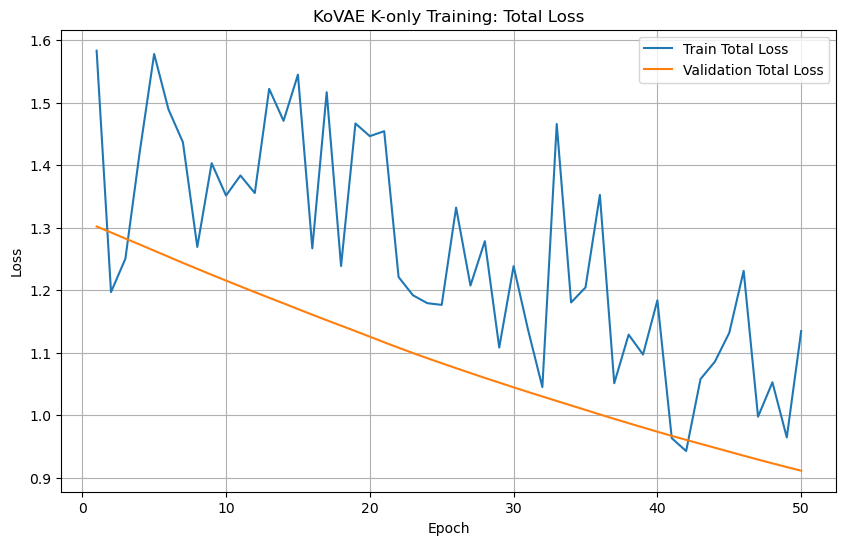

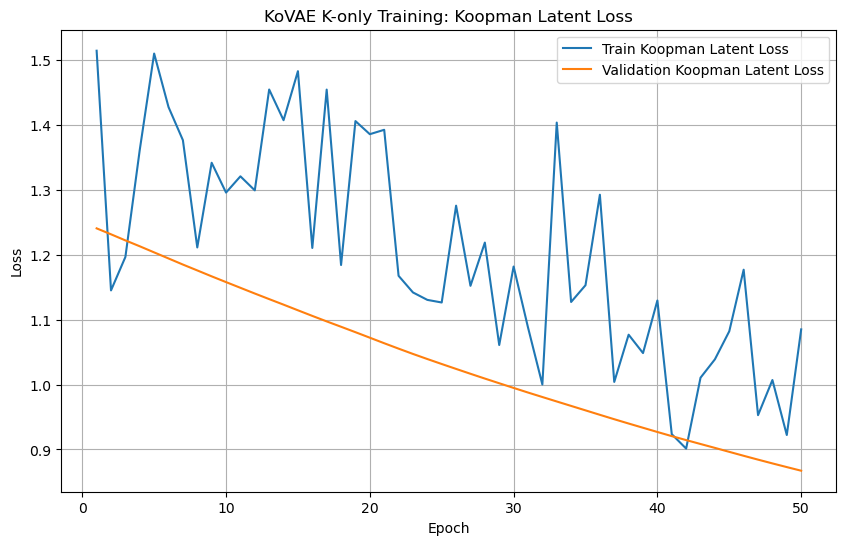

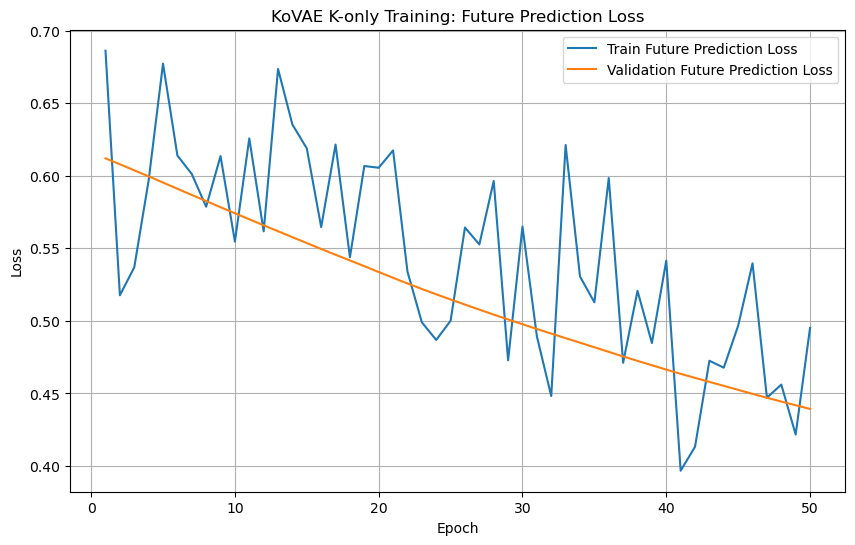

Figures saved successfully:
/home/iailab42/khans1/projects/results/kovae_konly_total_loss.png
/home/iailab42/khans1/projects/results/kovae_konly_koopman_latent_loss.png
/home/iailab42/khans1/projects/results/kovae_konly_future_prediction_loss.png


In [41]:
FIGURES_DIR = Path("/home/iailab42/khans1/projects/results")

epochs = range(1, EPOCHS + 1)

# Total loss plot
plt.figure(figsize=(10, 6))

plt.plot(epochs, train_history["total_loss"], label="Train Total Loss")
plt.plot(epochs, val_history["total_loss"], label="Validation Total Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("KoVAE K-only Training: Total Loss")
plt.legend()
plt.grid(True)

total_loss_fig_path = FIGURES_DIR / "kovae_konly_total_loss.png"
plt.savefig(total_loss_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# Koopman latent loss plot
plt.figure(figsize=(10, 6))

plt.plot(epochs, train_history["koopman_latent_loss"], label="Train Koopman Latent Loss")
plt.plot(epochs, val_history["koopman_latent_loss"], label="Validation Koopman Latent Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("KoVAE K-only Training: Koopman Latent Loss")
plt.legend()
plt.grid(True)

koopman_loss_fig_path = FIGURES_DIR / "kovae_konly_koopman_latent_loss.png"
plt.savefig(koopman_loss_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# Future prediction loss plot
plt.figure(figsize=(10, 6))

plt.plot(epochs, train_history["future_pred_loss"], label="Train Future Prediction Loss")
plt.plot(epochs, val_history["future_pred_loss"], label="Validation Future Prediction Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("KoVAE K-only Training: Future Prediction Loss")
plt.legend()
plt.grid(True)

future_pred_fig_path = FIGURES_DIR / "kovae_konly_future_prediction_loss.png"
plt.savefig(future_pred_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figures saved successfully:")
print(total_loss_fig_path)
print(koopman_loss_fig_path)
print(future_pred_fig_path)

### Test set evaluation

In [42]:
kovae.eval()
test_results = {
    "reconstruction_loss": [],
    "koopman_latent_loss": [],
    "future_prediction_loss": [],

    # Identity baseline means:
    # no learned Koopman transition
    # predicted z_next = z_t
    "identity_baseline_latent_loss": [],
    "identity_baseline_future_prediction_loss": []
}

channel_names = ["BVP", "ACC_X", "ACC_Y", "ACC_Z", "EDA", "TEMP"]

per_channel_future_mse_sum = torch.zeros(6, device=device)
per_channel_identity_mse_sum = torch.zeros(6, device=device)

num_batches = 0

with torch.no_grad():
    for x_t, x_next in test_loader:

        x_t = x_t.to(device)
        x_next = x_next.to(device)

        # ----------------------------------------------------
        # Forward pass through trained KoVAE
        # ----------------------------------------------------
        outputs = kovae(x_t, x_next)

        # ----------------------------------------------------
        # 1. Reconstruction loss
        # Checks:
        # recon_t vs x_t
        # ----------------------------------------------------
        reconstruction_loss = F.mse_loss(
            outputs["recon_t"],
            x_t
        )

        # ----------------------------------------------------
        # 2. Koopman latent loss
        # Checks:
        # K(z_t) vs z_next
        # ----------------------------------------------------
        koopman_latent_loss = F.mse_loss(
            outputs["z_next_pred"],
            outputs["z_next"]
        )

        # ----------------------------------------------------
        # 3. Future prediction loss
        # Checks:
        # decoder(K(z_t)) vs x_next
        # ----------------------------------------------------
        future_prediction_loss = F.mse_loss(
            outputs["pred_next"],
            x_next
        )

        # ----------------------------------------------------
        # Identity baseline
        # This means:
        # z_next_pred = z_t
        #
        # It answers:
        # Is trained K better than doing nothing?
        # ----------------------------------------------------
        z_identity_pred = outputs["z_t"]
        pred_next_identity = kovae.decoder(z_identity_pred)

        identity_latent_loss = F.mse_loss(
            z_identity_pred,
            outputs["z_next"]
        )

        identity_future_loss = F.mse_loss(
            pred_next_identity,
            x_next
        )

        # ----------------------------------------------------
        # Store batch losses
        # ----------------------------------------------------
        test_results["reconstruction_loss"].append(
            reconstruction_loss.item()
        )

        test_results["koopman_latent_loss"].append(
            koopman_latent_loss.item()
        )

        test_results["future_prediction_loss"].append(
            future_prediction_loss.item()
        )

        test_results["identity_baseline_latent_loss"].append(
            identity_latent_loss.item()
        )

        test_results["identity_baseline_future_prediction_loss"].append(
            identity_future_loss.item()
        )

        # ----------------------------------------------------
        # Per-channel MSE
        # This tells us which signal channel is predicted better/worse.
        # ----------------------------------------------------
        for ch in range(6):

            per_channel_future_mse_sum[ch] += F.mse_loss(
                outputs["pred_next"][:, ch, :],
                x_next[:, ch, :]
            )

            per_channel_identity_mse_sum[ch] += F.mse_loss(
                pred_next_identity[:, ch, :],
                x_next[:, ch, :]
            )

        num_batches += 1

test_summary = {}

for key, values in test_results.items():
    test_summary[key] = float(sum(values) / len(values))

per_channel_future_mse = per_channel_future_mse_sum / num_batches
per_channel_identity_mse = per_channel_identity_mse_sum / num_batches

# Improvement over identity baseline

latent_improvement = (
    test_summary["identity_baseline_latent_loss"]
    - test_summary["koopman_latent_loss"]
)

future_improvement = (
    test_summary["identity_baseline_future_prediction_loss"]
    - test_summary["future_prediction_loss"]
)

latent_improvement_percent = (
    latent_improvement
    / test_summary["identity_baseline_latent_loss"]
) * 100

future_improvement_percent = (
    future_improvement
    / test_summary["identity_baseline_future_prediction_loss"]
) * 100

print("Test-set evaluation finished.\n")

print("Overall test losses:")
print("Reconstruction loss:", test_summary["reconstruction_loss"])
print("Koopman latent loss:", test_summary["koopman_latent_loss"])
print("Future prediction loss:", test_summary["future_prediction_loss"])

print("\nIdentity baseline losses:")
print("Identity latent loss:", test_summary["identity_baseline_latent_loss"])
print("Identity future prediction loss:", test_summary["identity_baseline_future_prediction_loss"])

print("\nImprovement over identity baseline:")
print("Latent improvement:", latent_improvement)
print("Latent improvement %:", latent_improvement_percent)

print("Future prediction improvement:", future_improvement)
print("Future prediction improvement %:", future_improvement_percent)

print("\nPer-channel future prediction MSE:")
for i, name in enumerate(channel_names):
    print(
        f"{name:6s} | "
        f"KoVAE: {per_channel_future_mse[i].item():.6f} | "
        f"Identity: {per_channel_identity_mse[i].item():.6f}"
    )

Test-set evaluation finished.

Overall test losses:
Reconstruction loss: 0.026199580170214176
Koopman latent loss: 0.5830086668332418
Future prediction loss: 0.27653222779432934

Identity baseline losses:
Identity latent loss: 0.829245388507843
Identity future prediction loss: 0.3864331195751826

Improvement over identity baseline:
Latent improvement: 0.2462367216746012
Latent improvement %: 29.694071873909767
Future prediction improvement: 0.10990089178085327
Future prediction improvement %: 28.439822109882968

Per-channel future prediction MSE:
BVP    | KoVAE: 1.104023 | Identity: 1.552943
ACC_X  | KoVAE: 0.308244 | Identity: 0.438809
ACC_Y  | KoVAE: 0.099693 | Identity: 0.138016
ACC_Z  | KoVAE: 0.138485 | Identity: 0.182216
EDA    | KoVAE: 0.005683 | Identity: 0.004367
TEMP   | KoVAE: 0.003066 | Identity: 0.002247


In [43]:
RESULTS_DIR = Path("/home/iailab42/khans1/projects/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

test_result_path = RESULTS_DIR / f"kovae_konly_latent128_{EPOCHS}_test_results.json"

save_data = {
    "experiment_name": "kovae_konly_latent128",
    "description": "Test-set evaluation for KoVAE K-only model",

    "test_summary": test_summary,

    "improvement_over_identity": {
        "latent_improvement": float(latent_improvement),
        "latent_improvement_percent": float(latent_improvement_percent),
        "future_prediction_improvement": float(future_improvement),
        "future_prediction_improvement_percent": float(future_improvement_percent)
    },

    "per_channel_future_mse": {
        channel_names[i]: float(per_channel_future_mse[i].item())
        for i in range(6)
    },

    "per_channel_identity_future_mse": {
        channel_names[i]: float(per_channel_identity_mse[i].item())
        for i in range(6)
    }
}

with open(test_result_path, "w") as f:
    json.dump(save_data, f, indent=4)

end_time = time.time()

print("Test results saved successfully.")
print("Saved path:", test_result_path)

Test results saved successfully.
Saved path: /home/iailab42/khans1/projects/results/kovae_konly_latent128_50_test_results.json


### Visualization

In [46]:
kovae.eval()

sample_records = []

global_sample_idx = 0

with torch.no_grad():

    for batch_idx, (x_t, x_next) in enumerate(test_loader):

        x_t = x_t.to(device)
        x_next = x_next.to(device)

        outputs = kovae(x_t, x_next)

        pred_next_kovae = outputs["pred_next"]

        # Identity baseline: no Koopman transition
        pred_next_identity = kovae.decoder(outputs["z_t"])

        batch_size_now = x_t.size(0)

        for i in range(batch_size_now):

            kovae_mse = F.mse_loss(
                pred_next_kovae[i],
                x_next[i]
            ).item()

            identity_mse = F.mse_loss(
                pred_next_identity[i],
                x_next[i]
            ).item()

            improvement = identity_mse - kovae_mse

            improvement_percent = (
                improvement / identity_mse
            ) * 100 if identity_mse != 0 else 0.0

            sample_records.append({
                "global_sample_idx": global_sample_idx,
                "batch_idx": batch_idx,
                "within_batch_idx": i,
                "kovae_mse": kovae_mse,
                "identity_mse": identity_mse,
                "improvement": improvement,
                "improvement_percent": improvement_percent
            })

            global_sample_idx += 1


# Sort by improvement
sample_records_sorted = sorted(
    sample_records,
    key=lambda x: x["improvement"],
    reverse=True
)

best_sample = sample_records_sorted[0]
worst_sample = sample_records_sorted[-1]
median_sample = sample_records_sorted[len(sample_records_sorted) // 2]

print("Best sample:")
print(best_sample)

print("\nMedian sample:")
print(median_sample)

print("\nWorst sample:")
print(worst_sample)

Best sample:
{'global_sample_idx': 279, 'batch_idx': 4, 'within_batch_idx': 23, 'kovae_mse': 2.279484748840332, 'identity_mse': 3.6958446502685547, 'improvement': 1.4163599014282227, 'improvement_percent': 38.32303669271663}

Median sample:
{'global_sample_idx': 165, 'batch_idx': 2, 'within_batch_idx': 37, 'kovae_mse': 0.16157478094100952, 'identity_mse': 0.20862887799739838, 'improvement': 0.047054097056388855, 'improvement_percent': 22.553971199028172}

Worst sample:
{'global_sample_idx': 231, 'batch_idx': 3, 'within_batch_idx': 39, 'kovae_mse': 0.34454870223999023, 'identity_mse': 0.3361998498439789, 'improvement': -0.008348852396011353, 'improvement_percent': -2.483300453550418}


Per-channel MSE for selected test sample:

BVP    | KoVAE MSE: 0.379592 | Identity MSE: 0.543281
ACC_X  | KoVAE MSE: 0.018761 | Identity MSE: 0.011021
ACC_Y  | KoVAE MSE: 0.001768 | Identity MSE: 0.001639
ACC_Z  | KoVAE MSE: 0.002884 | Identity MSE: 0.002901
EDA    | KoVAE MSE: 0.001597 | Identity MSE: 0.000668
TEMP   | KoVAE MSE: 0.001951 | Identity MSE: 0.000581


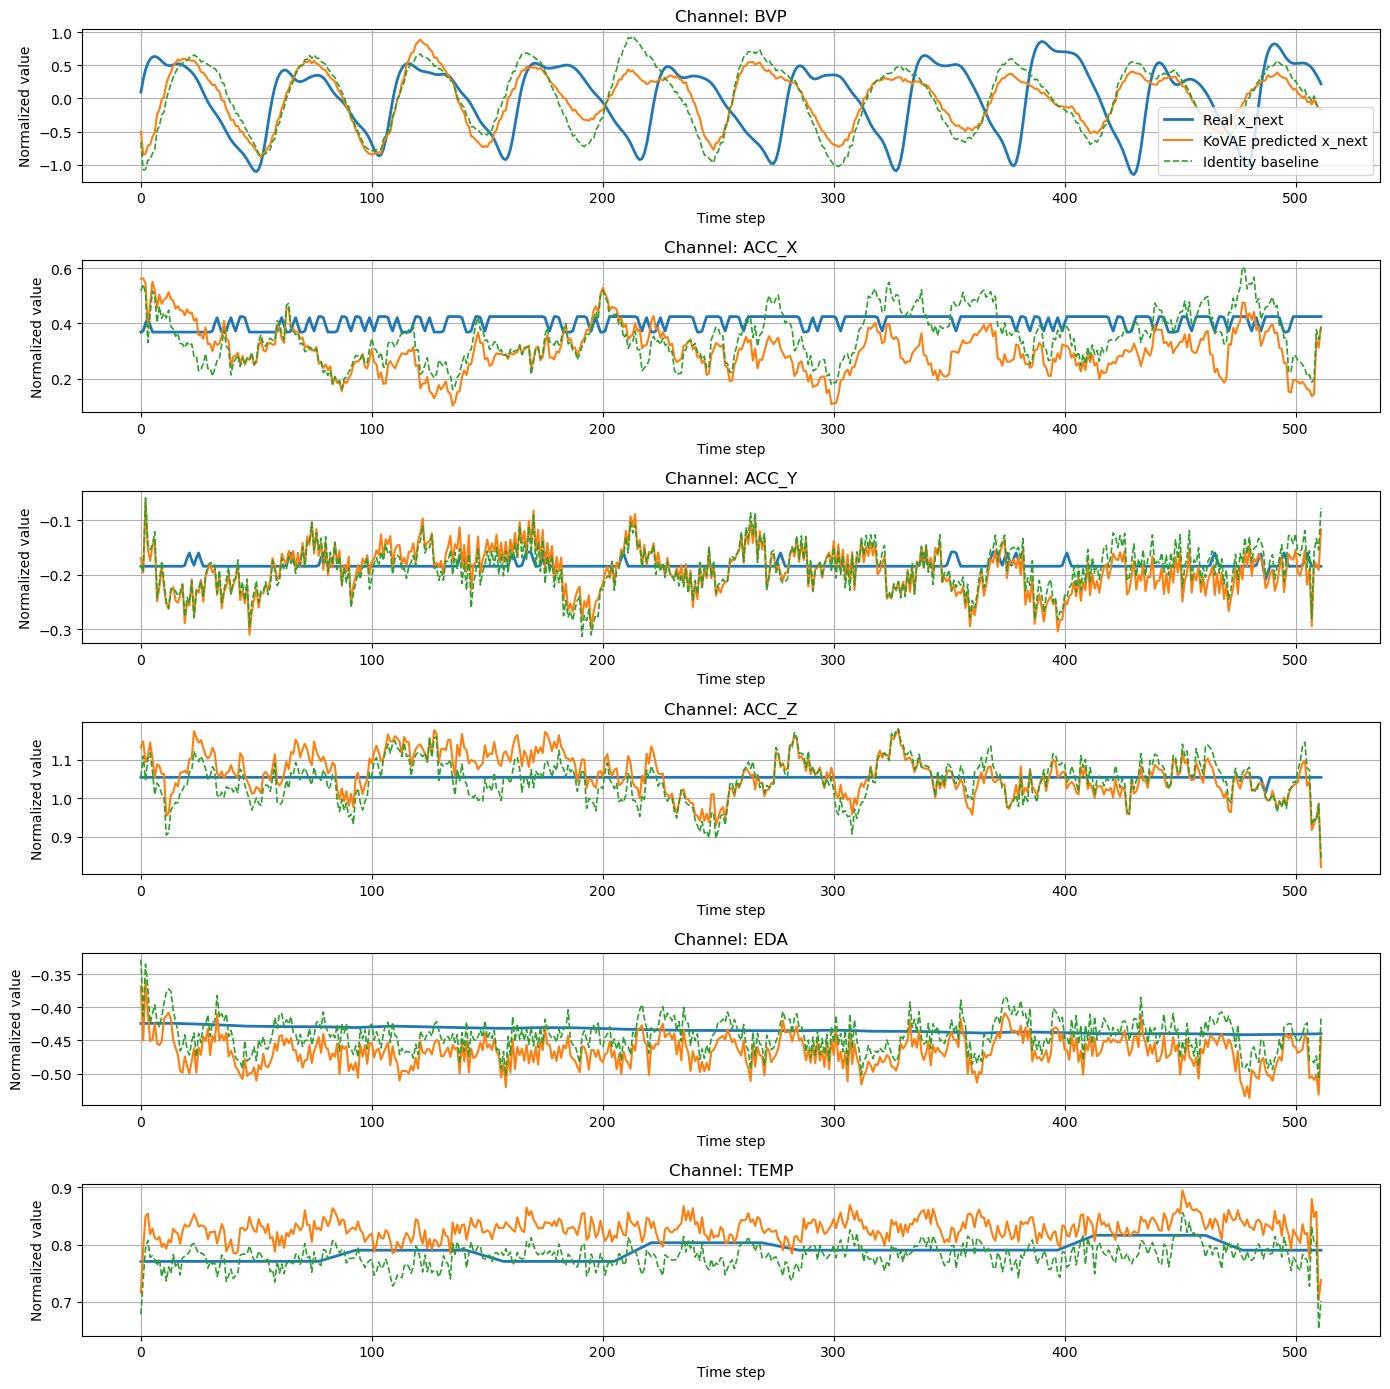

In [48]:
kovae.eval()

# ------------------------------------------------------------
# Take one batch from the test set
# ------------------------------------------------------------
with torch.no_grad():

    batch_x_t, batch_x_next = next(iter(test_loader))

    batch_x_t = batch_x_t.to(device)
    batch_x_next = batch_x_next.to(device)

    # KoVAE forward pass
    outputs = kovae(batch_x_t, batch_x_next)

    # KoVAE prediction:
    # x_t -> encoder -> z_t -> K -> z_next_pred -> decoder -> pred_next
    pred_next_kovae = outputs["pred_next"]

    # Identity baseline:
    # x_t -> encoder -> z_t -> decoder
    # This means: no Koopman transition
    pred_next_identity = kovae.decoder(outputs["z_t"])


# ------------------------------------------------------------
# Choose one sample from this batch
# ------------------------------------------------------------
sample_idx = best_sample["global_sample_idx"] % batch_x_t.size(0)

real_next = batch_x_next[sample_idx].detach().cpu()
kovae_pred = pred_next_kovae[sample_idx].detach().cpu()
identity_pred = pred_next_identity[sample_idx].detach().cpu()

channel_names = ["BVP", "ACC_X", "ACC_Y", "ACC_Z", "EDA", "TEMP"]

# ------------------------------------------------------------
# Print per-channel MSE for this selected sample
# ------------------------------------------------------------
print("Per-channel MSE for selected test sample:\n")

for ch, name in enumerate(channel_names):

    kovae_mse = F.mse_loss(
        pred_next_kovae[sample_idx, ch, :],
        batch_x_next[sample_idx, ch, :]
    ).item()

    identity_mse = F.mse_loss(
        pred_next_identity[sample_idx, ch, :],
        batch_x_next[sample_idx, ch, :]
    ).item()

    print(
        f"{name:6s} | "
        f"KoVAE MSE: {kovae_mse:.6f} | "
        f"Identity MSE: {identity_mse:.6f}"
    )


# ------------------------------------------------------------
# Plot all channels
# ------------------------------------------------------------
plt.figure(figsize=(14, 14))

for ch, name in enumerate(channel_names):

    plt.subplot(6, 1, ch + 1)

    plt.plot(
        real_next[ch],
        label="Real x_next",
        linewidth=2
    )

    plt.plot(
        kovae_pred[ch],
        label="KoVAE predicted x_next",
        linewidth=1.5
    )

    plt.plot(
        identity_pred[ch],
        label="Identity baseline",
        linewidth=1.2,
        linestyle="--"
    )

    plt.title(f"Channel: {name}")
    plt.xlabel("Time step")
    plt.ylabel("Normalized value")
    plt.grid(True)

    if ch == 0:
        plt.legend()

plt.tight_layout()
plt.show()

### Rollout synthetic data

In [49]:
kovae.eval()

# Robustly get Koopman layer, whether the model uses K or k
koopman_layer = kovae.k if hasattr(kovae, "k") else kovae.K

# ------------------------------------------------------------
# Rollout settings
# ------------------------------------------------------------
# ROLLOUT_STEPS = number of future Koopman transitions
# If ROLLOUT_STEPS = 10:
# we generate x_0, x_1, x_2, ..., x_10
# so total generated windows = 11
# ------------------------------------------------------------
ROLLOUT_STEPS = 10

with torch.no_grad():

    # --------------------------------------------------------
    # 1. Take one sequential batch from test set
    # --------------------------------------------------------
    # test_loader has shuffle=False, so samples are ordered.
    # This allows us to compare generated rollout with real future windows.
    # --------------------------------------------------------
    batch_x_t, batch_x_next = next(iter(test_loader))

    batch_x_t = batch_x_t.to(device)
    batch_x_next = batch_x_next.to(device)

    # --------------------------------------------------------
    # 2. Choose seed window
    # --------------------------------------------------------
    # We use the first current window as the starting point.
    # Shape: (1, 6, 512)
    # --------------------------------------------------------
    seed_x = batch_x_t[0:1]

    # --------------------------------------------------------
    # 3. Encode seed window into latent state z_0
    # --------------------------------------------------------
    # encoder returns mu and logvar.
    # For stable generation, we use mu as z_0.
    # --------------------------------------------------------
    mu_0, logvar_0 = kovae.encoder(seed_x)

    z_current = mu_0

    # --------------------------------------------------------
    # 4. Roll forward in latent space using Koopman K
    # --------------------------------------------------------
    # At each step:
    # z_current -> decoder -> synthetic window
    # z_current -> K -> next latent state
    # --------------------------------------------------------
    synthetic_windows = []
    latent_rollout = []

    for step in range(ROLLOUT_STEPS + 1):

        # Decode current latent state into a signal window
        synthetic_x = kovae.decoder(z_current)

        synthetic_windows.append(synthetic_x.squeeze(0).detach().cpu())
        latent_rollout.append(z_current.squeeze(0).detach().cpu())

        # Move to next latent state
        z_current = koopman_layer(z_current)

    # Convert list to tensor
    # Shape: (ROLLOUT_STEPS + 1, 6, 512)
    synthetic_windows = torch.stack(synthetic_windows)
    latent_rollout = torch.stack(latent_rollout)

    # --------------------------------------------------------
    # 5. Prepare real windows for comparison
    # --------------------------------------------------------
    # real_rollout[0] = real seed x_0
    # real_rollout[1] = real x_1
    # real_rollout[2] = real x_2
    # ...
    #
    # Because test_loader is ordered:
    # batch_x_next[0] is next window after batch_x_t[0]
    # batch_x_next[1] is the next one after that, etc.
    # --------------------------------------------------------
    real_rollout = torch.cat(
        [
            batch_x_t[0:1],
            batch_x_next[:ROLLOUT_STEPS]
        ],
        dim=0
    ).detach().cpu()


# ------------------------------------------------------------
# 6. Print shape checks
# ------------------------------------------------------------
print("Synthetic generation finished.\n")

print("Seed window shape:", seed_x.shape)
print("Synthetic rollout shape:", synthetic_windows.shape)
print("Real rollout shape:", real_rollout.shape)
print("Latent rollout shape:", latent_rollout.shape)

# ------------------------------------------------------------
# 7. Step-wise MSE against real future windows
# ------------------------------------------------------------
print("\nStep-wise rollout MSE:")

rollout_mse_values = []

for step in range(ROLLOUT_STEPS + 1):

    mse = F.mse_loss(
        synthetic_windows[step],
        real_rollout[step]
    ).item()

    rollout_mse_values.append(mse)

    print(f"Step {step:02d} | MSE: {mse:.6f}")

Synthetic generation finished.

Seed window shape: torch.Size([1, 6, 512])
Synthetic rollout shape: torch.Size([11, 6, 512])
Real rollout shape: torch.Size([11, 6, 512])
Latent rollout shape: torch.Size([11, 128])

Step-wise rollout MSE:
Step 00 | MSE: 0.009216
Step 01 | MSE: 0.087169
Step 02 | MSE: 0.175455
Step 03 | MSE: 0.986089
Step 04 | MSE: 1.334131
Step 05 | MSE: 0.901331
Step 06 | MSE: 0.820943
Step 07 | MSE: 0.870587
Step 08 | MSE: 0.621281
Step 09 | MSE: 0.606250
Step 10 | MSE: 0.545916


Synthetic rollout shape: (11, 6, 512)
Real rollout shape: (11, 6, 512)
Synthetic long shape: (6, 5632)
Real long shape: (6, 5632)


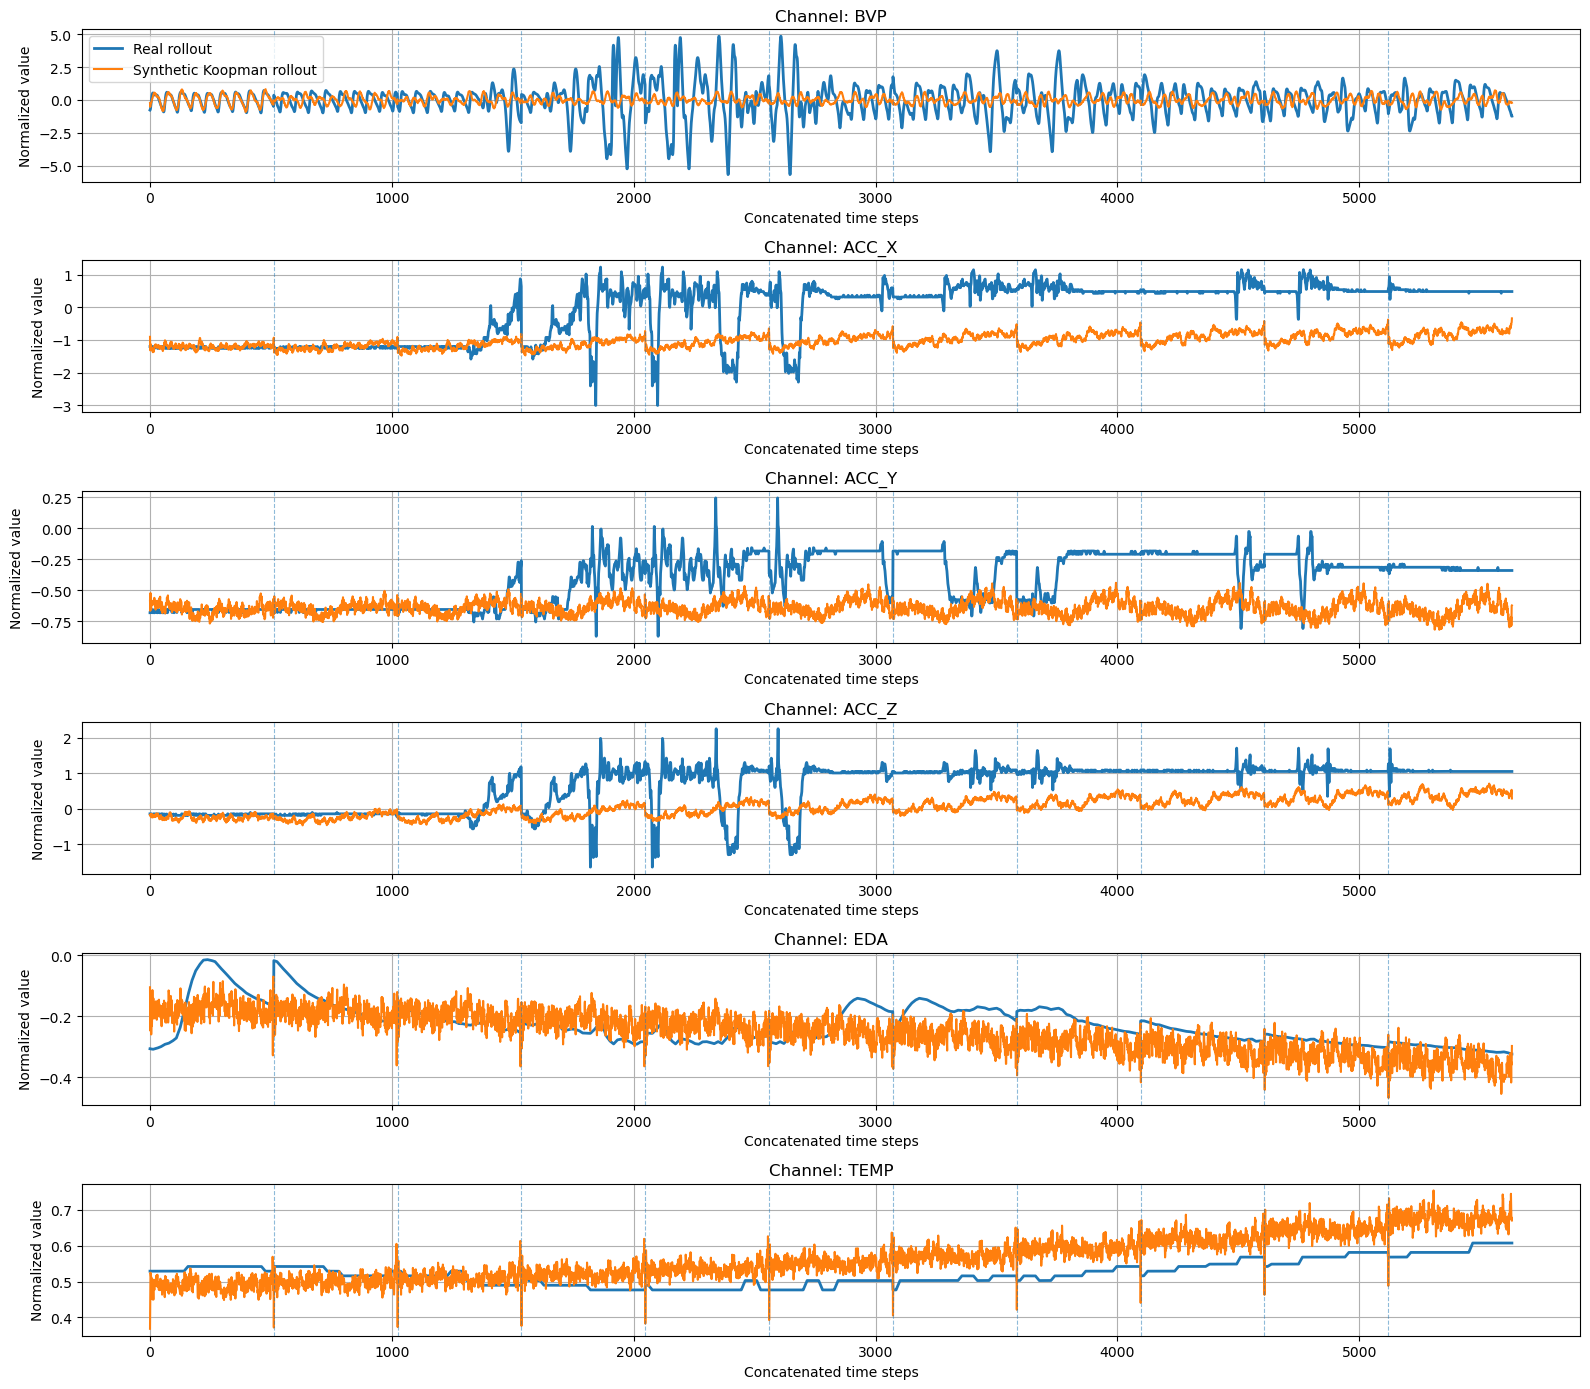

In [50]:
# ------------------------------------------------------------
# Convert rollout tensors to NumPy
# synthetic_windows shape: (11, 6, 512)
# real_rollout shape:      (11, 6, 512)
# ------------------------------------------------------------
synthetic_np = synthetic_windows.numpy()
real_np = real_rollout.numpy()

num_steps = synthetic_np.shape[0]
num_channels = synthetic_np.shape[1]
window_length = synthetic_np.shape[2]

channel_names = ["BVP", "ACC_X", "ACC_Y", "ACC_Z", "EDA", "TEMP"]

print("Synthetic rollout shape:", synthetic_np.shape)
print("Real rollout shape:", real_np.shape)

# ------------------------------------------------------------
# Concatenate windows into one long sequence
# Shape:
# (num_steps, channels, window_length)
# becomes
# (channels, num_steps * window_length)
# ------------------------------------------------------------
synthetic_long = synthetic_np.transpose(1, 0, 2).reshape(
    num_channels,
    num_steps * window_length
)

real_long = real_np.transpose(1, 0, 2).reshape(
    num_channels,
    num_steps * window_length
)

print("Synthetic long shape:", synthetic_long.shape)
print("Real long shape:", real_long.shape)

# ------------------------------------------------------------
# Plot all channels
# ------------------------------------------------------------
plt.figure(figsize=(16, 14))

for ch, name in enumerate(channel_names):

    plt.subplot(6, 1, ch + 1)

    plt.plot(
        real_long[ch],
        label="Real rollout",
        linewidth=2
    )

    plt.plot(
        synthetic_long[ch],
        label="Synthetic Koopman rollout",
        linewidth=1.5
    )

    # Add vertical lines to show window boundaries
    for step in range(1, num_steps):
        plt.axvline(
            x=step * window_length,
            linestyle="--",
            linewidth=0.8,
            alpha=0.5
        )

    plt.title(f"Channel: {name}")
    plt.xlabel("Concatenated time steps")
    plt.ylabel("Normalized value")
    plt.grid(True)

    if ch == 0:
        plt.legend()

plt.tight_layout()
plt.show()